In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_master = pd.read_csv("Final_Master_Dataset.csv")

In [4]:
df_master.head(10)

,Date,Gold_Reservs_USD_mn,Gold_Volume_mn_troy_oz,Gold_Price[/10gm],Gold_CPI,USDINR,Repo_Rate,Overall_CPI,Inflation_YoY,Inflation_MoM,FPI_Net_INR_Crore,""" """"GDP current prices (Billions of U.S. dollars)""""""",""" """"GDP per capita current prices (U.S. dollars per capita)""""""",Real GDP growth (Annual percent change),Remittances received (Personal remittances received current U.S. $)
0,2000-01,2945.0,11.502339,4510.75,---,43.59,---,---,---,---,196.5,468.396 ...,442.751 ...,3.8,12883465957
1,2000-02,3104.0,11.502339,4712.25,---,43.65,---,---,---,---,3084.2,468.396 ...,442.751 ...,3.8,12883465957
2,2000-03,2974.0,11.502339,4541.90,---,43.64,---,---,---,---,1198.9,468.396 ...,442.751 ...,3.8,12883465957
3,2000-04,2895.0,11.502339,4462.06,---,43.68,---,---,---,---,2586.7,468.396 ...,442.751 ...,3.8,12883465957
4,2000-05,2851.0,11.502339,4371.14,---,44.08,---,---,---,---,252.9,468.396 ...,442.751 ...,3.8,12883465957
5,2000-06,2948.0,11.502339,4522.95,---,44.76,---,---,---,---,-935.1,468.396 ...,442.751 ...,3.8,12883465957
6,2000-07,2924.0,11.502339,4530.25,---,44.84,---,---,---,---,-1401.9,468.396 ...,442.751 ...,3.8,12883465957
7,2000-08,2830.0,11.502339,4517.25,---,45.77,---,---,---,---,1258.9,468.396 ...,442.751 ...,3.8,12883465957
8,2000-09,2834.0,11.502339,4517.78,---,45.97,---,---,---,---,218.4,468.396 ...,442.751 ...,3.8,12883465957
9,2000-10,2800.0,11.502339,4536.32,---,46.43,---,---,---,---,-218.6,468.396 ...,442.751 ...,3.8,12883465957


In [5]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 15 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Date                                                                  315 non-null    object 
 1    Gold_Reservs_USD_mn                                                  315 non-null    float64
 2    Gold_Volume_mn_troy_oz                                               315 non-null    float64
 3    Gold_Price[/10gm]                                                    315 non-null    float64
 4    Gold_CPI                                                             315 non-null    object 
 5    USDINR                                                               315 non-null    float64
 6    Repo_Rate                                                            315 non-null    object 
 7  

In [6]:
df_master.duplicated().sum()

0

# **What is Gold Anomaly Detection?**

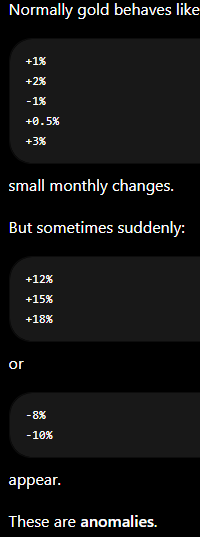

In [7]:
# print(df_master.columns.tolist())

df_master.columns = df_master.columns.str.strip()
print(df_master.columns.tolist())

['Date', 'Gold_Reservs_USD_mn', 'Gold_Volume_mn_troy_oz', 'Gold_Price[/10gm]', 'Gold_CPI', 'USDINR', 'Repo_Rate', 'Overall_CPI', 'Inflation_YoY', 'Inflation_MoM', 'FPI_Net_INR_Crore', '" ""GDP current prices (Billions of U.S. dollars)"""', '" ""GDP per capita current prices (U.S. dollars per capita)"""', 'Real GDP growth (Annual percent change)', 'Remittances received (Personal remittances received current U.S. $)']


In [8]:
df_master['Gold_Return_%'] = (
    df_master['Gold_Price[/10gm]']
    .pct_change()
    * 100
)

In [9]:
df_master.head(10)

,Date,Gold_Reservs_USD_mn,Gold_Volume_mn_troy_oz,Gold_Price[/10gm],Gold_CPI,USDINR,Repo_Rate,Overall_CPI,Inflation_YoY,Inflation_MoM,FPI_Net_INR_Crore,""" """"GDP current prices (Billions of U.S. dollars)""""""",""" """"GDP per capita current prices (U.S. dollars per capita)""""""",Real GDP growth (Annual percent change),Remittances received (Personal remittances received current U.S. $),Gold_Return_%
0,2000-01,2945.0,11.502339,4510.75,---,43.59,---,---,---,---,196.5,468.396 ...,442.751 ...,3.8,12883465957,NaN
1,2000-02,3104.0,11.502339,4712.25,---,43.65,---,---,---,---,3084.2,468.396 ...,442.751 ...,3.8,12883465957,4.467106
2,2000-03,2974.0,11.502339,4541.90,---,43.64,---,---,---,---,1198.9,468.396 ...,442.751 ...,3.8,12883465957,-3.615046
3,2000-04,2895.0,11.502339,4462.06,---,43.68,---,---,---,---,2586.7,468.396 ...,442.751 ...,3.8,12883465957,-1.757855
4,2000-05,2851.0,11.502339,4371.14,---,44.08,---,---,---,---,252.9,468.396 ...,442.751 ...,3.8,12883465957,-2.037624
5,2000-06,2948.0,11.502339,4522.95,---,44.76,---,---,---,---,-935.1,468.396 ...,442.751 ...,3.8,12883465957,3.473007
6,2000-07,2924.0,11.502339,4530.25,---,44.84,---,---,---,---,-1401.9,468.396 ...,442.751 ...,3.8,12883465957,0.161399
7,2000-08,2830.0,11.502339,4517.25,---,45.77,---,---,---,---,1258.9,468.396 ...,442.751 ...,3.8,12883465957,-0.286960
8,2000-09,2834.0,11.502339,4517.78,---,45.97,---,---,---,---,218.4,468.396 ...,442.751 ...,3.8,12883465957,0.011733
9,2000-10,2800.0,11.502339,4536.32,---,46.43,---,---,---,---,-218.6,468.396 ...,442.751 ...,3.8,12883465957,0.410379


In [10]:
df_master['Gold_Return_%'].describe()

count    314.000000
mean       1.183587
std        3.706775
min      -10.274561
25%       -1.156393
50%        0.772474
75%        3.072742
max       15.513790
Name: Gold_Return_%, dtype: float64

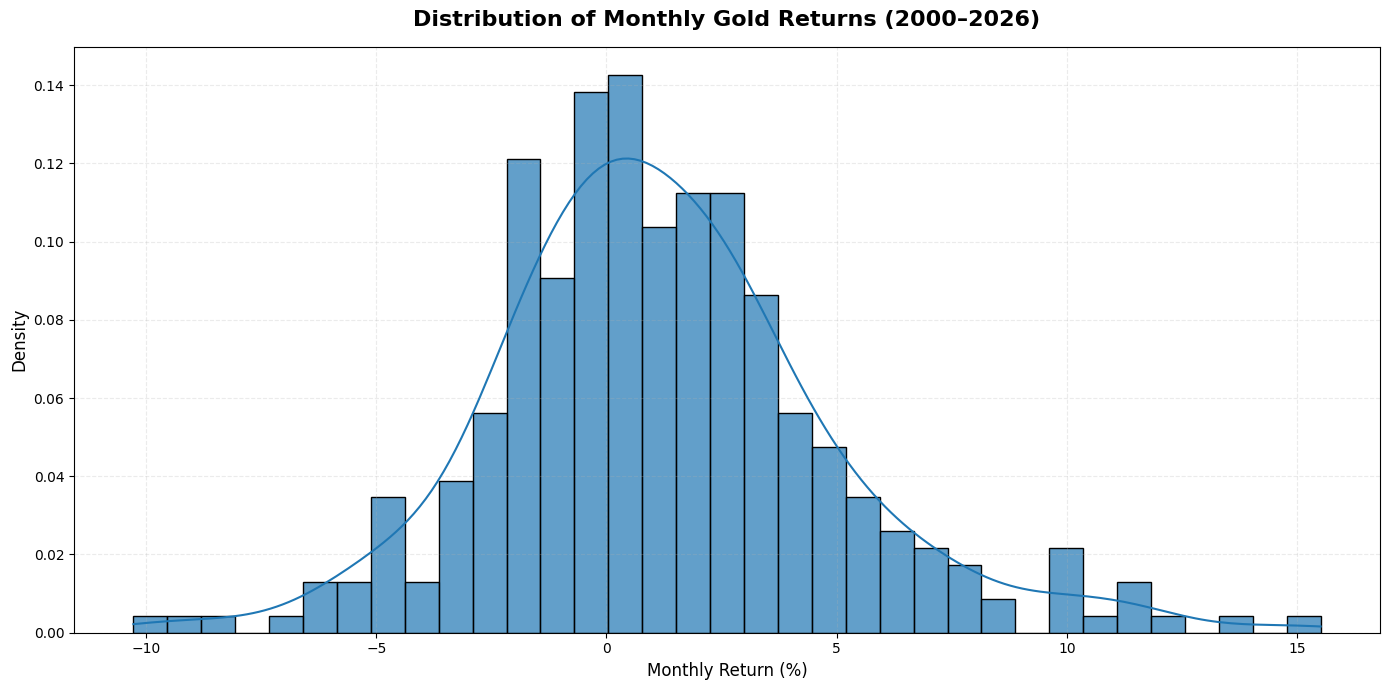

In [12]:
plt.figure(figsize=(14,7))

sns.histplot(
    data=df_master,
    x='Gold_Return_%',
    bins=35,
    kde=True,
    stat='density',
    alpha=0.7
)

plt.title(
    'Distribution of Monthly Gold Returns (2000–2026)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Monthly Return (%)',
    fontsize=12
)

plt.ylabel(
    'Density',
    fontsize=12
)

plt.grid(
    alpha=0.25,
    linestyle='--'
)

plt.tight_layout()

plt.show()

In [13]:
mean_return = df_master['Gold_Return_%'].mean()
std_return = df_master['Gold_Return_%'].std()
upper_limit = mean_return + 2*std_return
lower_limit = mean_return - 2*std_return
print(f'Mean Return: {mean_return:.2f}%')
print(f'Standard Deviation: {std_return:.2f}%')
print(f'Upper Limit: {upper_limit:.2f}%')
print(f'Lower Limit: {lower_limit:.2f}%')

Mean Return: 1.18%
Standard Deviation: 3.71%
Upper Limit: 8.60%
Lower Limit: -6.23%


In [14]:
gold_anomalies = df_master[
    (df_master['Gold_Return_%'] > upper_limit)
    |
    (df_master['Gold_Return_%'] < lower_limit)
]

In [15]:
gold_anomalies[
    ['Date',
     'Gold_Price[/10gm]',
     'Gold_Return_%']
]
gold_anomalies

,Date,Gold_Reservs_USD_mn,Gold_Volume_mn_troy_oz,Gold_Price[/10gm],Gold_CPI,USDINR,Repo_Rate,Overall_CPI,Inflation_YoY,Inflation_MoM,FPI_Net_INR_Crore,""" """"GDP current prices (Billions of U.S. dollars)""""""",""" """"GDP per capita current prices (U.S. dollars per capita)""""""",Real GDP growth (Annual percent change),Remittances received (Personal remittances received current U.S. $),Gold_Return_%
75,2006-04,6301.00,11.501953,8987.06,---,44.82,6.5,---,---,---,772.0,940.26 ...,801.669 ...,8.1,28333642280,11.363817
76,2006-05,7010.00,11.501953,9965.00,---,45.20,6.5,---,---,---,-6647.0,940.26 ...,801.669 ...,8.1,28333642280,10.881645
77,2006-06,6180.00,11.501953,8941.14,---,45.89,6.75,---,---,---,874.0,940.26 ...,801.669 ...,8.1,28333642280,-10.274561
96,2008-01,9199.00,11.501953,11295.00,---,39.27,7.75,---,---,---,-11084.0,1198.895 ...,992.519 ...,3.1,49977276916,9.758337
99,2008-04,9427.00,11.501953,11814.75,---,39.97,7.75,---,---,---,-626.0,1198.895 ...,992.519 ...,3.1,49977276916,-6.521111
103,2008-08,8692.00,11.501953,11835.75,---,42.91,9,---,---,---,46.0,1198.895 ...,992.519 ...,3.1,49977276916,-9.122913
109,2009-02,9746.00,11.501953,14778.68,---,49.25,5.5,---,---,---,-3125.0,1341.889 ...,1094.95 ...,7.9,49203912009,9.625586
139,2011-08,28319.00,17.932098,25826.25,141.2,45.31,8,---,---,---,-7904.0,1823.052 ...,1445.461 ...,5.2,62499075445,14.039542
163,2013-08,21724.10,17.932098,30178.82,158.5,62.81,7.25,112.4,---,1.26,-15698.0,1847.019 ...,1425.357 ...,6.4,69970360847,11.895041
203,2016-12,18584.10,17.932740,28169.05,97,67.81,6.25,130.4,3.41,-0.61,-27110.0,2264.818 ...,1685.202 ...,8.3,62744364090,-7.284333


In [16]:
top_gainers = (
    df_master
    .nlargest(
        15,
        'Gold_Return_%'
    )
)

In [17]:
top_gainers[
    ['Date',
     'Gold_Return_%']
]

,Date,Gold_Return_%
243,2020-04,15.513790
139,2011-08,14.039542
163,2013-08,11.895041
309,2025-10,11.652357
75,2006-04,11.363817
312,2026-01,11.305941
76,2006-05,10.881645
286,2023-11,9.961567
308,2025-09,9.879120
96,2008-01,9.758337


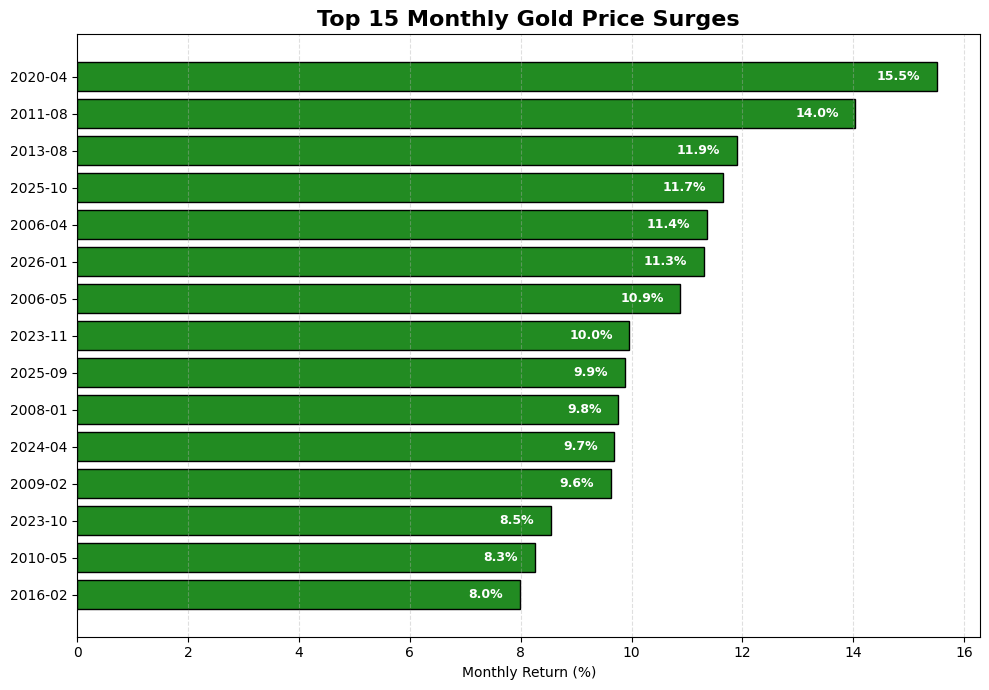

In [18]:
top_gainers_plot = (
    top_gainers
    .sort_values('Gold_Return_%')
)

plt.figure(figsize=(10,7))

bars = plt.barh(
    top_gainers_plot['Date'],
    top_gainers_plot['Gold_Return_%'],
    color='forestgreen',
    edgecolor='black'
)

plt.title(
    'Top 15 Monthly Gold Price Surges',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Monthly Return (%)')

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

for bar in bars:

    width = bar.get_width()

    plt.text(
        width - 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        ha='right',
        fontsize=9,
        color='white',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [19]:
top_losers = (
    df_master
    .nsmallest(
        15,
        'Gold_Return_%'
    )
)

In [20]:
top_losers[
    ['Date',
     'Gold_Return_%']
]


,Date,Gold_Return_%
77,2006-06,-10.274561
103,2008-08,-9.122913
269,2022-06,-8.585500
203,2016-12,-7.284333
99,2008-04,-6.521111
38,2003-03,-6.183450
159,2013-04,-6.076123
80,2006-09,-5.803660
270,2022-07,-5.341554
254,2021-03,-5.142425


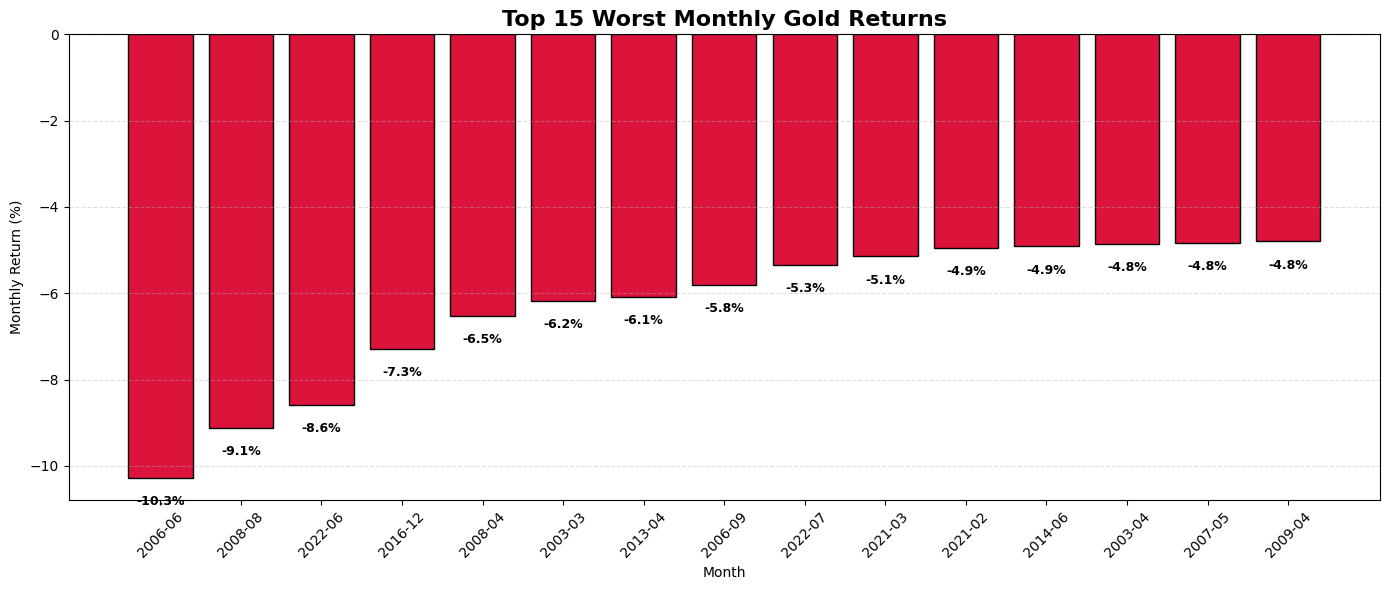

In [21]:
plt.figure(figsize=(14,6))

bars = plt.bar(
    top_losers['Date'],
    top_losers['Gold_Return_%'],
    color='crimson',
    edgecolor='black'
)

plt.title(
    'Top 15 Worst Monthly Gold Returns',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Monthly Return (%)')

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# Value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height - 0.4,
        f'{height:.1f}%',
        ha='center',
        va='top',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [22]:
df_master['Date'] = pd.to_datetime(df_master['Date'])

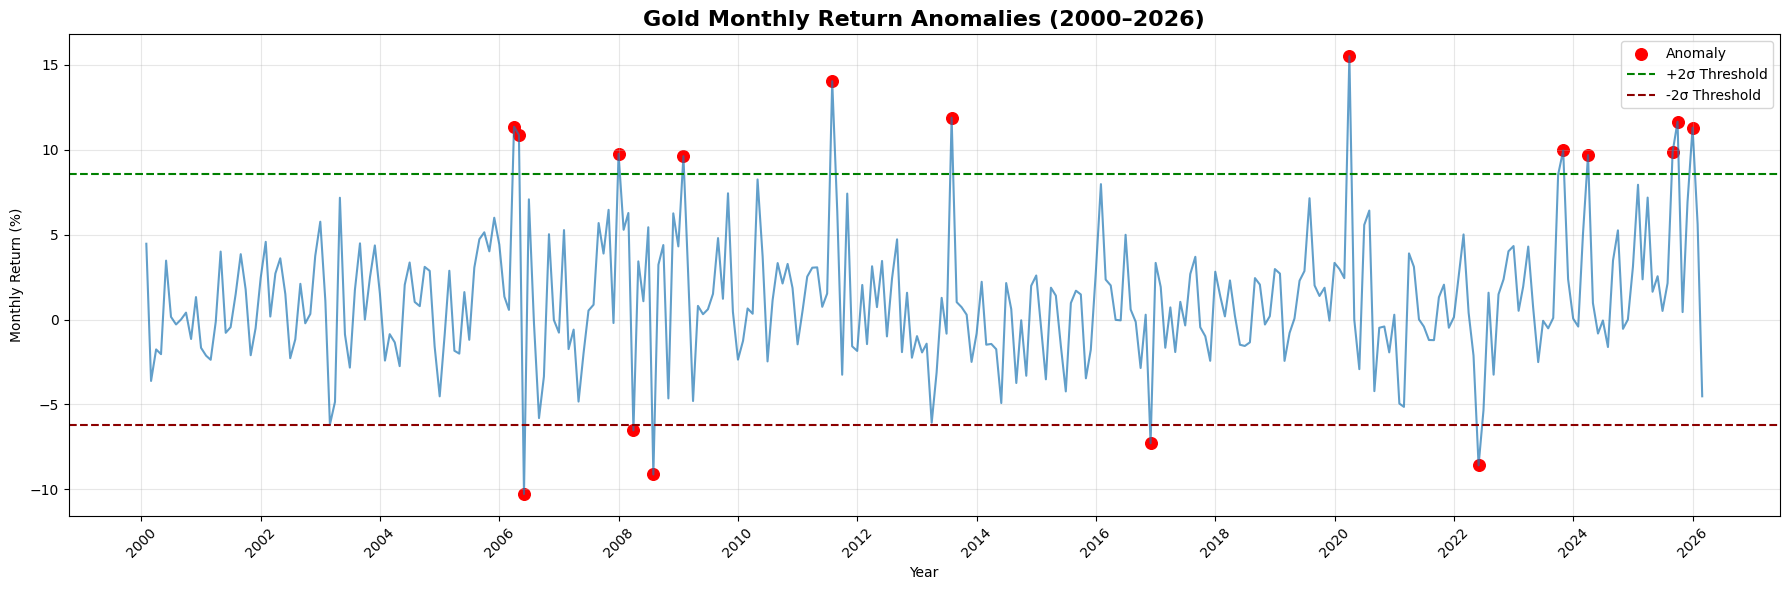

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(18,6))

plt.plot(
    df_master['Date'],
    df_master['Gold_Return_%'],
    alpha=0.7,
    linewidth=1.5
)

plt.scatter(
    gold_anomalies['Date'],
    gold_anomalies['Gold_Return_%'],
    color='red',
    s=70,
    label='Anomaly'
)

plt.axhline(
    upper_limit,
    linestyle='--',
    color='green',
    label='+2σ Threshold'
)

plt.axhline(
    lower_limit,
    linestyle='--',
    color='darkred',
    label='-2σ Threshold'
)

# Show only years
ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.YearLocator(2)   # every 2 years
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

plt.xticks(rotation=45)

plt.title(
    'Gold Monthly Return Anomalies (2000–2026)',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Monthly Return (%)')
plt.xlabel('Year')

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
event_analysis = pd.DataFrame({

    'Date': [
        '2006-04',
        '2006-05',
        '2006-06',
        '2008-01',
        '2008-04',
        '2008-08',
        '2009-02',
        '2011-08',
        '2013-08',
        '2016-12',
        '2020-04',
        '2022-06',
        '2023-11',
        '2024-04',
        '2025-09',
        '2025-10',
        '2026-01'
    ],

    'Return_%': [
        11.36,
        10.88,
        -10.27,
        9.76,
        -6.52,
        -9.12,
        9.63,
        14.04,
        11.90,
        -7.28,
        15.51,
        -8.59,
        9.96,
        9.69,
        9.88,
        11.65,
        11.31
    ],

    'Event': [

        'Commodity Rally',
        'Commodity Rally',
        'Profit Booking',

        'Pre-GFC Uncertainty',
        'GFC Volatility Begins',
        'Global Financial Crisis',

        'Flight to Safety',

        'Euro Debt Crisis',
        'Taper Tantrum & INR Crisis',

        'Post US Election & Demonetization',

        'COVID Pandemic',

        'Russia-Ukraine War',

        'Israel-Hamas Conflict',

        'Election Year & Central Bank Buying',

        'Global Gold Rally',
        'Tariff / Geopolitical Tension',
        'Continuation of Safe-Haven Demand'
    ],

    'Economic_Explanation': [

        'Strong global commodity demand pushed precious metal prices higher.',

        'Bullish commodity cycle increased investor interest in gold.',

        'Sharp correction after rapid gains and profit booking by investors.',

        'Investors began moving toward safer assets before the financial crisis intensified.',

        'Financial market instability increased volatility in gold prices.',

        'Global market panic caused large portfolio shifts and abnormal gold movements.',

        'Investors sought safe-haven assets amid financial uncertainty.',

        'European sovereign debt concerns and US credit downgrade boosted gold demand.',

        'Rupee depreciation and taper fears sharply increased domestic gold prices.',

        'Market uncertainty after demonetization and global political events.',

        'Lockdowns, uncertainty, and safe-haven demand drove a historic surge in gold.',

        'War-driven inflation fears and central bank tightening created volatility.',

        'Geopolitical tensions increased demand for safe assets.',

        'Election uncertainty and record central-bank purchases supported gold prices.',

        'Strong global demand and expectations of monetary easing.',

        'Trade/tariff concerns and geopolitical uncertainty increased safe-haven buying.',

        'Continuation of global uncertainty and persistent demand for gold.'
    ]
})

In [36]:
event_analysis

,Date,Return_%,Event,Economic_Explanation
0,2006-04,11.36,Commodity Rally,Strong global commodity demand pushed precious...
1,2006-05,10.88,Commodity Rally,Bullish commodity cycle increased investor int...
2,2006-06,-10.27,Profit Booking,Sharp correction after rapid gains and profit ...
3,2008-01,9.76,Pre-GFC Uncertainty,Investors began moving toward safer assets bef...
4,2008-04,-6.52,GFC Volatility Begins,Financial market instability increased volatil...
5,2008-08,-9.12,Global Financial Crisis,Global market panic caused large portfolio shi...
6,2009-02,9.63,Flight to Safety,Investors sought safe-haven assets amid financ...
7,2011-08,14.04,Euro Debt Crisis,European sovereign debt concerns and US credit...
8,2013-08,11.90,Taper Tantrum & INR Crisis,Rupee depreciation and taper fears sharply inc...
9,2016-12,-7.28,Post US Election & Demonetization,Market uncertainty after demonetization and gl...


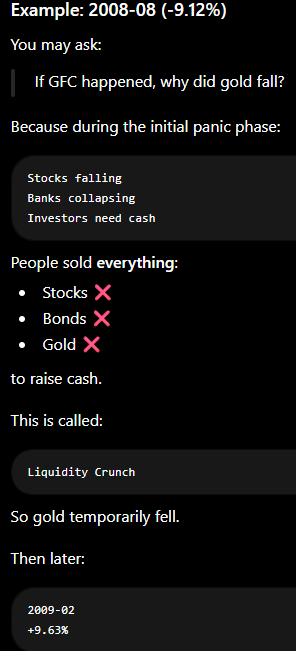

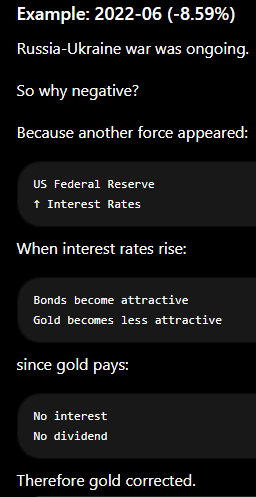

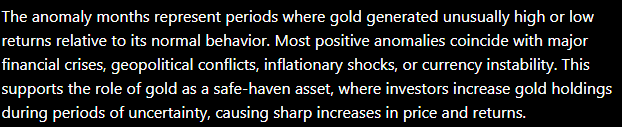

In [37]:
event_analysis.to_csv(
    "Gold_Anomaly_Event_Analysis.csv",
    index=False
)

In [38]:
events = {
    '2008-09':'GFC',
    '2011-08':'Euro Crisis',
    '2013-08':'Taper Tantrum',
    '2016-11':'Demonetization',
    '2020-03':'COVID',
    '2022-02':'Ukraine War',
    '2023-10':'Israel-Hamas',
    '2024-06':'Election'
}

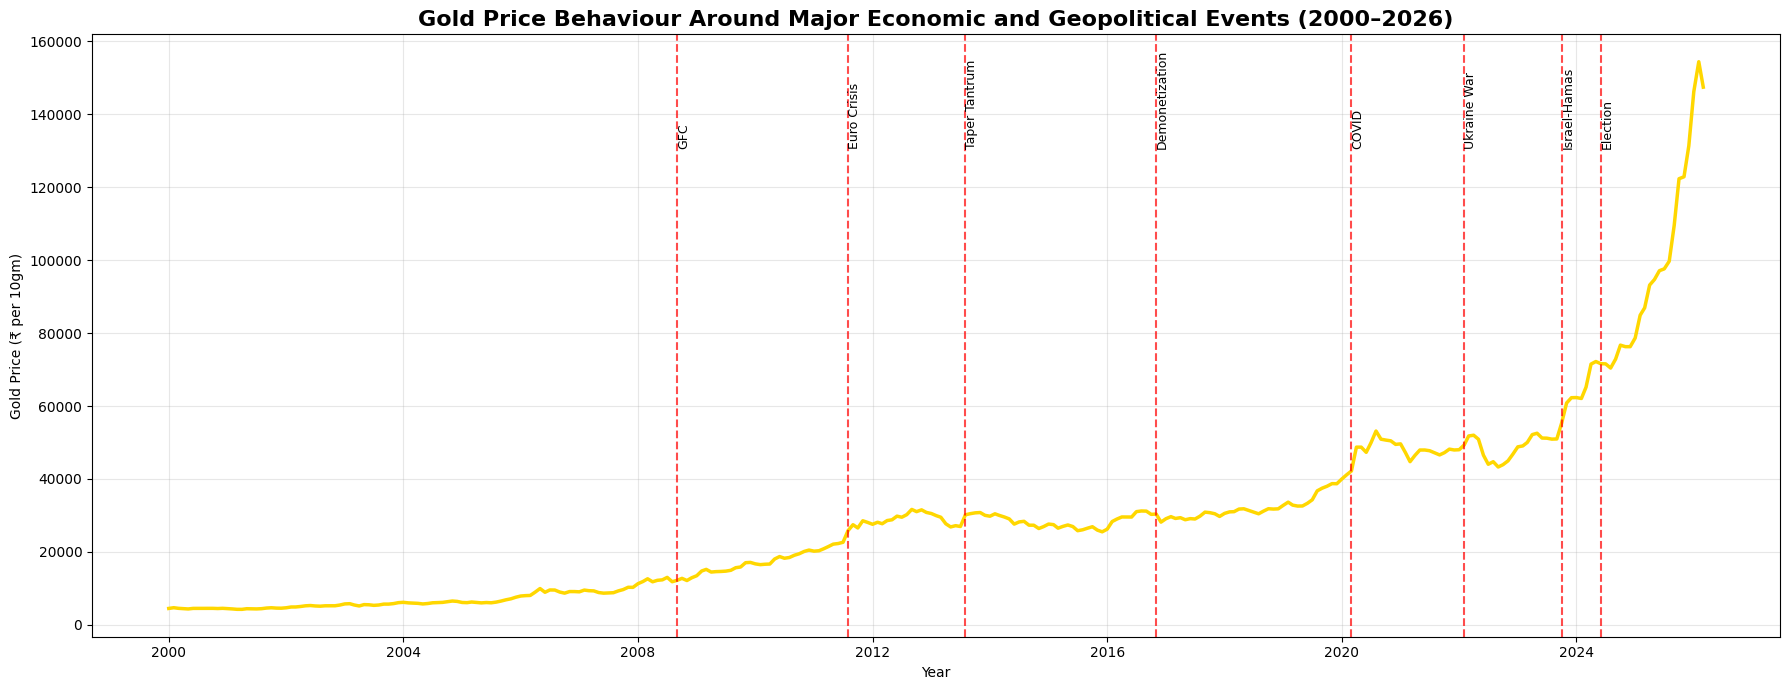

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

df_master['Date'] = pd.to_datetime(df_master['Date'])

plt.figure(figsize=(18,7))

plt.plot(
    df_master['Date'],
    df_master['Gold_Price[/10gm]'],
    linewidth=2.5,
    color='gold'
)

for date,event in events.items():

    plt.axvline(
        pd.to_datetime(date),
        linestyle='--',
        alpha=0.7,
        color='red'
    )

    plt.text(
        pd.to_datetime(date),
        df_master['Gold_Price[/10gm]'].max()*0.85,
        event,
        rotation=90,
        fontsize=9
    )

plt.title(
    'Gold Price Behaviour Around Major Economic and Geopolitical Events (2000–2026)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Gold Price (₹ per 10gm)')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

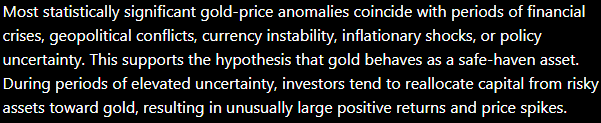

# **Gold During the Modern Crisis Era (2020–2026)**

In [41]:
df_recent = df_master[
    (df_master['Date'] >= '2020-01')
].copy()

In [42]:
df_recent

,Date,Gold_Reservs_USD_mn,Gold_Volume_mn_troy_oz,Gold_Price[/10gm],Gold_CPI,USDINR,Repo_Rate,Overall_CPI,Inflation_YoY,Inflation_MoM,FPI_Net_INR_Crore,""" """"GDP current prices (Billions of U.S. dollars)""""""",""" """"GDP per capita current prices (U.S. dollars per capita)""""""",Real GDP growth (Annual percent change),Remittances received (Personal remittances received current U.S. $),Gold_Return_%
240,2020-01-01,28997.49,20.414669,39987.74,135.5,71.28,5.15,150.2,7.59,-0.13,957.0,2611.953 ...,1862.198 ...,-5.8,83149172934,3.340204
241,2020-02-01,29896.83,20.634671,41174.35,139.4,71.53,5.15,149.1,6.58,-0.73,8970.0,2611.953 ...,1862.198 ...,-5.8,83149172934,2.967435
242,2020-03-01,30578.16,20.994727,42179.57,---,74.55,4.4,148.6,5.84,-0.34,-118203.0,2611.953 ...,1862.198 ...,-5.8,83149172934,2.441374
243,2020-04-01,32277.30,21.054800,48723.22,---,76.17,4.4,151.4,7.22,1.88,-14859.0,2611.953 ...,1862.198 ...,-5.8,83149172934,15.513790
244,2020-05-01,32897.70,21.144805,48723.22,---,75.66,4,150.9,6.27,-0.33,-7356.0,2611.953 ...,1862.198 ...,-5.8,83149172934,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,2025-11-01,106740.00,28.298487,122834.00,408.4,88.84,5.5,197.9,0.71,0.3,2836.0,3916.312 ...,2675.322 ...,7.6,---,0.441312
311,2025-12-01,111262.00,28.303688,131322.55,433.9,90.04,5.25,198,1.33,0.05,-38568.0,3916.312 ...,2675.322 ...,7.6,---,6.910587
312,2026-01-01,126904.00,28.303707,146169.80,---,90.90,5.25,---,2.38,0,-29240.0,--- ...,--- ...,---,---,11.305941
313,2026-02-01,131630.00,28.303709,154370.40,---,90.75,5.25,---,2.86,0,37804.0,--- ...,--- ...,---,---,5.610324


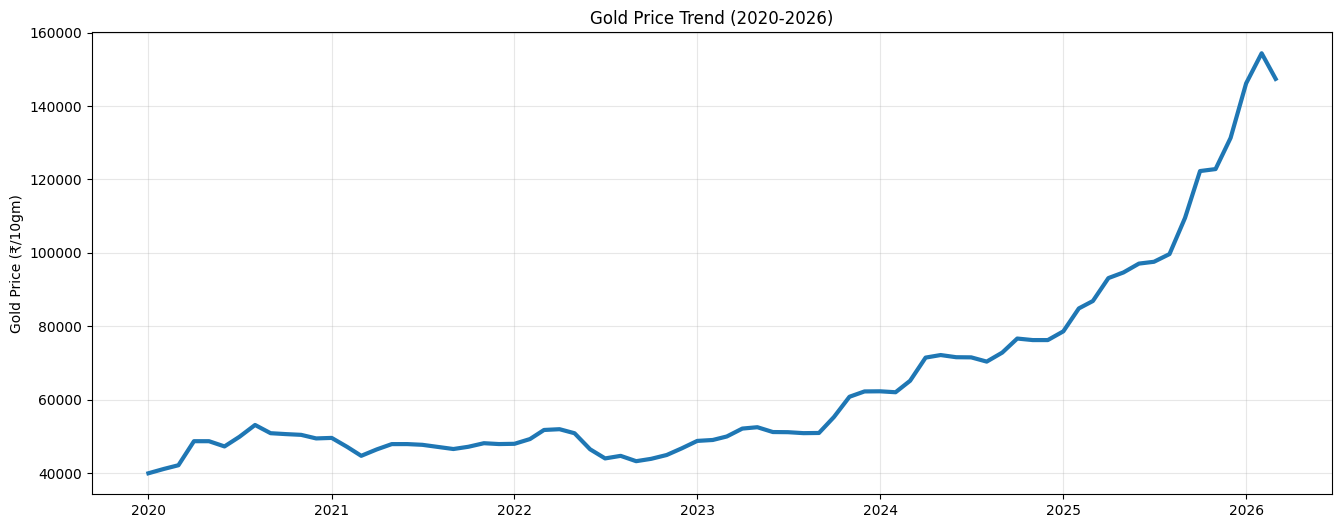

In [43]:
plt.figure(figsize=(16,6))

plt.plot(
    df_recent['Date'],
    df_recent['Gold_Price[/10gm]'],
    linewidth=3
)

plt.title(
    'Gold Price Trend (2020-2026)'
)

plt.ylabel('Gold Price (₹/10gm)')

plt.grid(alpha=0.3)

plt.show()

In [44]:
# %Growth
start_price = df_recent['Gold_Price[/10gm]'].iloc[0]

end_price = df_recent['Gold_Price[/10gm]'].iloc[-1]

growth = (
    (end_price-start_price)
    / start_price
)*100

print(growth)

268.6004760459081


In [45]:
# %CAGR
years = 6

cagr = (
    (end_price/start_price)**(1/years)-1
)*100

print(cagr)

24.287079180544513


In [46]:
#Monthly returns

df_recent['Return_%'] = (
    df_recent['Gold_Price[/10gm]']
    .pct_change()
    *100
)

In [47]:
volatility = (
    df_recent['Return_%']
    .std()
)

print(volatility)

4.311185467532906


In [48]:
full_vol = (
    df_master['Gold_Return_%']
    .std()
)

recent_vol = (
    df_recent['Return_%']
    .std()
)

In [51]:
print("Full Volatility is:",full_vol)
print("Recent Volatility is:",recent_vol)

Full Volatility is: 3.706774502506652
Recent Volatility is: 4.311185467532906


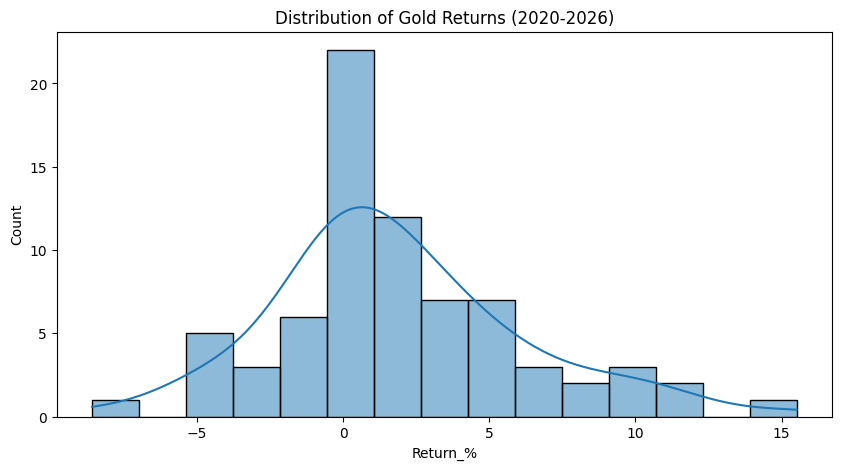

In [52]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_recent['Return_%'],
    bins=15,
    kde=True
)

plt.title(
    'Distribution of Gold Returns (2020-2026)'
)

plt.show()

In [53]:
df_recent['Rolling_Volatility'] = (
    df_recent['Return_%']
    .rolling(12)
    .std()
)

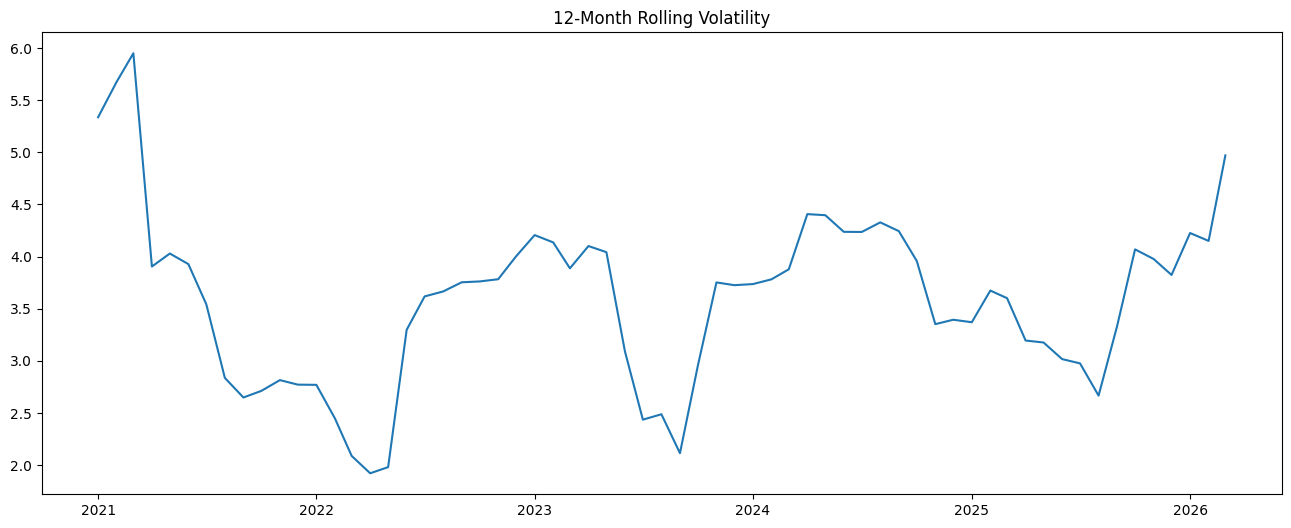

In [54]:
plt.figure(figsize=(16,6))

plt.plot(
    df_recent['Date'],
    df_recent['Rolling_Volatility']
)

plt.title(
    '12-Month Rolling Volatility'
)

plt.show()

In [55]:
recent = df_master[
    df_master['Date'] >= '2020-01'
].copy()

recent['Year'] = (
    pd.to_datetime(recent['Date'])
    .dt.year
)

year_stats = []

for year,grp in recent.groupby('Year'):

    start = grp['Gold_Price[/10gm]'].iloc[0]
    end = grp['Gold_Price[/10gm]'].iloc[-1]

    yearly_return = (
        (end-start)/start
    )*100

    volatility = (
        grp['Gold_Return_%']
        .std()
    )

    year_stats.append({
        'Year':year,
        'Return_%':yearly_return,
        'Volatility_%':volatility,
        'Avg_Price':grp['Gold_Price[/10gm]'].mean()
    })

year_stats_df = pd.DataFrame(year_stats)

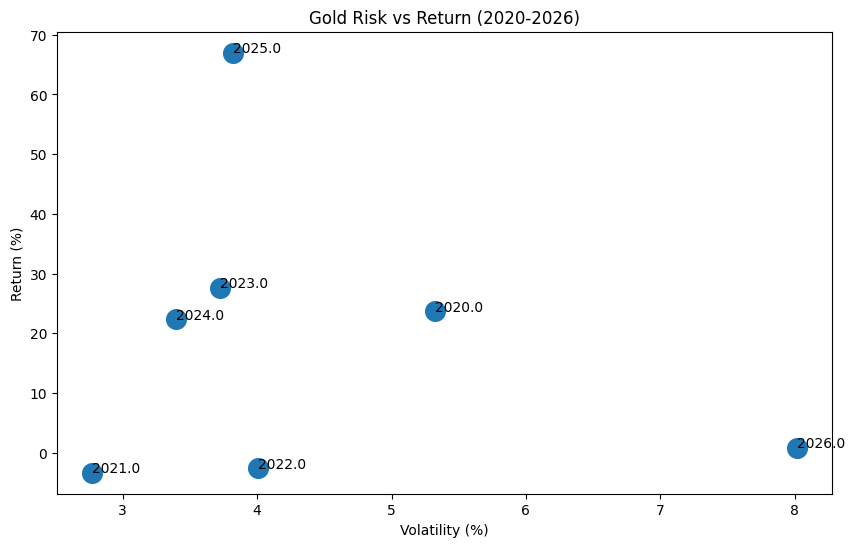

In [56]:
plt.figure(figsize=(10,6))

plt.scatter(
    year_stats_df['Volatility_%'],
    year_stats_df['Return_%'],
    s=200
)

for i,row in year_stats_df.iterrows():

    plt.text(
        row['Volatility_%'],
        row['Return_%'],
        row['Year']
    )

plt.xlabel('Volatility (%)')
plt.ylabel('Return (%)')

plt.title(
    'Gold Risk vs Return (2020-2026)'
)

plt.show()

In [57]:
recent = df_master[
    df_master['Date'] >= '2020-01'
].copy()

recent['Year'] = pd.to_datetime(
    recent['Date']
).dt.year

year_stats = []

for year, grp in recent.groupby('Year'):

    start_price = grp['Gold_Price[/10gm]'].iloc[0]
    end_price = grp['Gold_Price[/10gm]'].iloc[-1]

    annual_return = (
        (end_price - start_price)
        / start_price
    ) * 100

    annual_volatility = (
        grp['Gold_Return_%']
        .std()
    )

    year_stats.append({
        'Year': str(year),
        'Return_%': annual_return,
        'Volatility_%': annual_volatility
    })

year_stats_df = pd.DataFrame(year_stats)

year_stats_df

,Year,Return_%,Volatility_%
0,2020,23.735775,5.323164
1,2021,-3.375574,2.771880
2,2022,-2.580753,4.002626
3,2023,27.608536,3.725771
4,2024,22.387653,3.394384
5,2025,66.987529,3.823857
6,2026,0.838203,8.015110


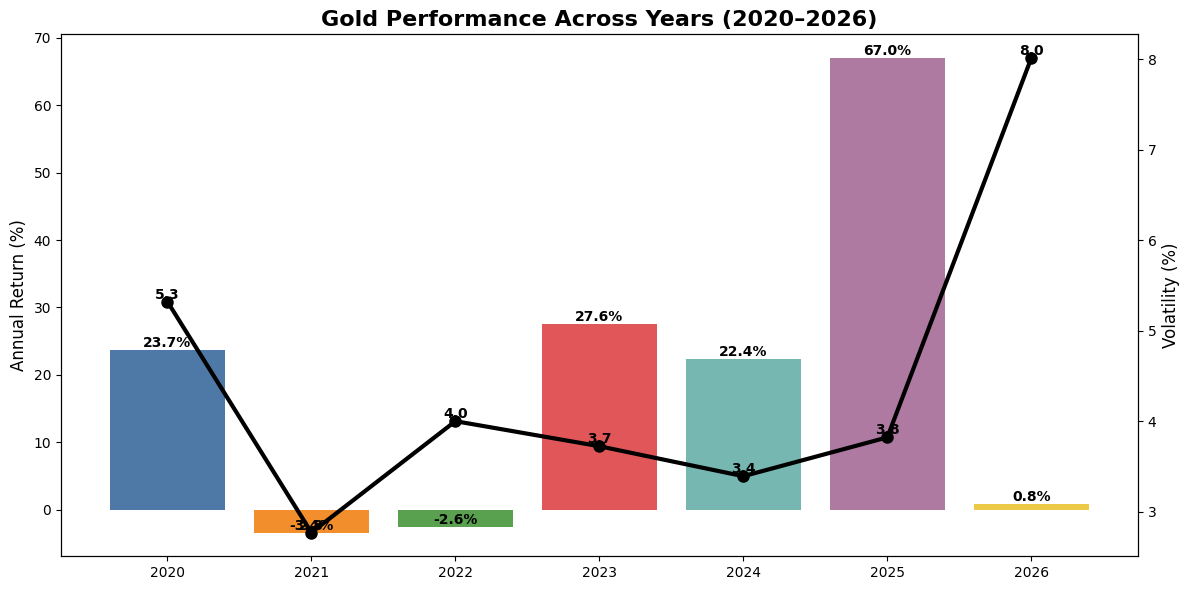

In [59]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

bars = ax1.bar(
    year_stats_df['Year'],
    year_stats_df['Return_%'],
    color=[
        '#4e79a7',
        '#f28e2b',
        '#59a14f',
        '#e15759',
        '#76b7b2',
        '#af7aa1',
        '#edc948'
    ]
)

ax1.set_ylabel(
    'Annual Return (%)',
    fontsize=12
)

ax1.set_title(
    'Gold Performance Across Years (2020–2026)',
    fontsize=16,
    fontweight='bold'
)

for bar,val in zip(
    bars,
    year_stats_df['Return_%']
):

    ax1.text(
        bar.get_x()+bar.get_width()/2,
        val,
        f'{val:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax2 = ax1.twinx()

ax2.plot(
    year_stats_df['Year'],
    year_stats_df['Volatility_%'],
    marker='o',
    linewidth=3,
    markersize=8,
    color='black'
)

ax2.set_ylabel(
    'Volatility (%)',
    fontsize=12
)

for x,y in zip(
    year_stats_df['Year'],
    year_stats_df['Volatility_%']
):

    ax2.text(
        x,
        y,
        f'{y:.1f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()